# DSA activity recognition — Adaptive transfer (paper-style comparisons)

This notebook reproduces **part of the experimental story** from *Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data* (Zhang et al.) using **real UCI DSA data** in PyHealth.

## Environment (use the project venv)

From the repo root:

```bash
python3 -m venv .venv   # if you do not already have it
source .venv/bin/activate
pip install -e ".[dev]"   # or your usual PyHealth install
pip install jupyter matplotlib
```

**IPD (DTW path):** implemented in this notebook with **NumPy** (multivariate DTW) and **scikit-learn** `KernelDensity` for the paper-style KDE step—no extra DTW packages.

Register this venv as a Jupyter kernel (optional but recommended):

```bash
.venv/bin/python -m ipykernel install --user --name=pyhealth-venv --display-name="PyHealth (.venv)"
```

Then open this notebook and choose the **PyHealth (.venv)** kernel.

**Why:** The repo targets a current Python (3.10+); the system `python3` may be too old for PyHealth’s syntax.

## What is implemented here

- **Domains:** Each on-body unit (`T`, `RA`, `LA`, `RL`, `LL`) is treated as a sensor *domain* with a single-unit input `(125 × 9)`, matching the paper’s multi-source view of DSA.
- **Target domain:** One held-out unit (default `LL`). **Sources:** the other four units.
- **Split:** Subject-level train / val / test via `split_by_patient` semantics (same segment index aligns across units — `sample_id` matches).
- **Model:** `AdaptiveTransferModel` (paper-aligned **LSTM(64)** or optional **`backbone="mlp"`**) + `Trainer`. **Classification:** 19-class DSA activity recognition (AAAI reproducibility plan), not the INFORMS paper’s one-vs-rest binary protocol.
- **IPD:** Configurable via `IPD_METRIC`. **`dtw`** (default) uses **multivariate DTW** on raw `(time × channels)` (squared Euclidean local cost, NumPy DP, sqrt path cost), plus optional **`sklearn.neighbors.KernelDensity`** summary matching `training_loop.py`. **`embedding`** uses encoder distances from `AdaptiveTransferModel`.
- **Paper-aligned comparisons (conceptual):**
  - **No transfer:** train only on the target domain.
  - **Direct transfer:** sequential pre-training on *all* source domains (fixed canonical order), then fine-tune on the target.
  - **Adaptive / IPD-ranked transfer:** rank sources with **Inter-domain Pairwise Distance (IPD)** using a short *probe* model on the target, then pre-train sources in that order with **similarity-scaled learning rates** (`get_adaptive_lr`).
  - **No pairing (ablation):** same pipeline as adaptive, but **random** source order (destroys paired relevance).
- **Ablations (model flags):** KDE smoothing on/off, similarity weighting on/off, distance metric (`euclidean`, `cosine`, `manhattan`).
- **Noise stress test:** Gaussian noise on test inputs (related to robustness claims in the paper).

## Fair comparison note

With `IPD_METRIC="dtw"`, IPD uses the same **multivariate DTW geometry** (Euclidean local cost) as common reference implementations. **Do not expect numerical RCC/accuracy to match the paper tables**; the notebook focuses on *relative* behavior.

## Data path

Default: `HealthTimeSerial/data` under the repository root (same layout as `scripts/dsa_real_data_sample.ipynb`). Adjust `DSA_ROOT` if your tree differs.


In [1]:
# Project stack (pyproject): numpy, scikit-learn, torch, … — use the project venv.
pass


In [2]:
from __future__ import annotations

import os
import random
import sys
import warnings
from dataclasses import dataclass
from itertools import chain
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.neighbors import KernelDensity

warnings.filterwarnings("ignore", category=UserWarning)

# --- Repo root (notebook cwd is usually repo root or examples/) ---
_CWD = Path.cwd().resolve()
if (_CWD / "pyhealth").is_dir():
    REPO_ROOT = _CWD
elif (_CWD.parent / "pyhealth").is_dir():
    REPO_ROOT = _CWD.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the PyHealth repo root or from examples/."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pyhealth.datasets import DSADataset, get_dataloader
from pyhealth.datasets.utils import collate_fn_dict_with_padding
from pyhealth.models.adaptive_transfer import AdaptiveTransferModel
from pyhealth.tasks import DSAActivityClassification
from pyhealth.trainer import Trainer

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

print("Python:", sys.executable)
print("Repo root:", REPO_ROOT)


/Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/bin/python
Repo root: /Users/tomiyoshi/DataspellProjects/PyHealth


In [3]:
# --- Configuration ---
DSA_ROOT = Path(os.environ.get("DSA_ROOT", REPO_ROOT / "HealthTimeSerial" / "data")).resolve()
TARGET_UNIT = "LL"  # paper-style single-source target
ALL_UNITS = ("T", "RA", "LA", "RL", "LL")
SOURCE_UNITS = tuple(u for u in ALL_UNITS if u != TARGET_UNIT)

SEED = 598
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
BATCH_SIZE = 64
HIDDEN_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.2

EPOCHS_PROBE = 2
EPOCHS_PRETRAIN_PER_SOURCE = 2
EPOCHS_FINETUNE = 5

# Set True for full ablation grid (slower)
RUN_FULL_ABLATIONS = False

# IPD: "dtw" = NumPy multivariate DTW + optional sklearn KDE (paper-style).
#       "embedding" = encoder distances via AdaptiveTransferModel.
IPD_METRIC = "dtw"

# Paper KDE (training_loop.py): KernelDensity + mean(sample(n)); set False for plain mean of DTWs.
IPD_USE_PAPER_KDE = True
IPD_KDE_BANDWIDTH = 7.8
IPD_KDE_DRAWS = 10
IPD_KDE_RANDOM_STATE = 0

# If IPD_USE_PAPER_KDE is False: add Gaussian noise to each paired DTW before averaging (legacy).
IPD_USE_GAUSSIAN_NOISE = True
IPD_KDE_NOISE_STD = 0.01

if not DSA_ROOT.is_dir():
    raise FileNotFoundError(
        f"DSA_ROOT not found: {DSA_ROOT}\n"
        "Download UCI DSA and place a01…a19 / p1… / sXX.txt under this path, "
        "or set DSA_ROOT in the environment."
    )

print("DSA_ROOT:", DSA_ROOT)
print("TARGET_UNIT:", TARGET_UNIT, "| SOURCES:", SOURCE_UNITS)
print("DEVICE:", DEVICE)


DSA_ROOT: /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data
TARGET_UNIT: LL | SOURCES: ('T', 'RA', 'LA', 'RL')
DEVICE: mps


In [4]:
def patient_split_indices(
    dataset,
    ratios: Tuple[float, float, float] = (0.5, 0.25, 0.25),
    seed: int = SEED,
) -> Dict[str, List[int]]:
    rng = np.random.default_rng(seed)
    patient_ids = list(dataset.patient_to_index.keys())
    rng.shuffle(patient_ids)
    n = len(patient_ids)
    n_train = int(n * ratios[0])
    n_val = int(n * ratios[1])
    train_p = patient_ids[:n_train]
    val_p = patient_ids[n_train : n_train + n_val]
    test_p = patient_ids[n_train + n_val :]

    def expand(patients):
        return list(chain(*[dataset.patient_to_index[pid] for pid in patients]))

    return {
        "train": expand(train_p),
        "val": expand(val_p),
        "test": expand(test_p),
        "train_patients": train_p,
        "val_patients": val_p,
        "test_patients": test_p,
    }


def subset_dataset(ds, indices: Sequence[int]):
    return ds.subset(list(indices))


@dataclass
class DomainBundle:
    unit: str
    full: object
    train: object
    val: object
    test: object


def build_domain_datasets(
    base: DSADataset,
    root: Path,
    units: Sequence[str],
    split: Dict[str, List[int]],
    num_workers: int = 1,
) -> Dict[str, DomainBundle]:
    out: Dict[str, DomainBundle] = {}
    for u in units:
        task = DSAActivityClassification(
            dataset_root=str(root),
            selected_units=(u,),
        )
        full = base.set_task(task, num_workers=num_workers)
        out[u] = DomainBundle(
            unit=u,
            full=full,
            train=subset_dataset(full, split["train"]),
            val=subset_dataset(full, split["val"]),
            test=subset_dataset(full, split["test"]),
        )
    return out


def make_loaders(train_ds, val_ds, test_ds, batch_size: int = BATCH_SIZE):
    train_loader = get_dataloader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = get_dataloader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = get_dataloader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def collate_indices(ds, indices: Sequence[int], batch_size: int) -> List[Dict]:
    out = []
    for i in range(0, len(indices), batch_size):
        chunk = indices[i : i + batch_size]
        rows = [ds[j] for j in chunk]
        out.append(collate_fn_dict_with_padding(rows))
    return out


def _signals_numpy_from_batch(batch: Dict, key: str = "signal") -> np.ndarray:
    sig = batch[key]
    if isinstance(sig, tuple):
        sig = sig[0]
    if hasattr(sig, "detach"):
        arr = sig.detach().cpu().float().numpy()
    else:
        arr = np.asarray(sig, dtype=np.float64)
    if arr.ndim == 2:
        arr = arr[:, :, np.newaxis]
    return arr


def multivariate_dtw_numpy(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.ndim != 2 or y.ndim != 2 or x.shape[1] != y.shape[1]:
        raise ValueError(f"Expected (T1, D) and (T2, D); got {x.shape}, {y.shape}")
    diff = x[:, None, :] - y[None, :, :]
    cost = np.sum(diff * diff, axis=2)
    n, m = cost.shape
    acc = np.full((n + 1, m + 1), np.inf, dtype=np.float64)
    acc[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            acc[i, j] = cost[i - 1, j - 1] + min(
                acc[i - 1, j], acc[i, j - 1], acc[i - 1, j - 1]
            )
    return float(np.sqrt(acc[n, m]))


def paired_multivariate_dtw_distances(
    ba: Dict, bb: Dict, feature_key: str = "signal"
) -> np.ndarray:
    xs = _signals_numpy_from_batch(ba, feature_key)
    ys = _signals_numpy_from_batch(bb, feature_key)
    if xs.shape[0] != ys.shape[0]:
        raise ValueError("Paired IPD requires matching batch sizes.")
    out = np.empty(xs.shape[0], dtype=np.float64)
    for i in range(xs.shape[0]):
        out[i] = multivariate_dtw_numpy(xs[i], ys[i])
    return out


def paper_kde_sample_mean(
    distances: np.ndarray,
    bandwidth: float = 7.8,
    n_draws: int = 10,
    random_state: int = 0,
) -> float:
    d = np.asarray(distances, dtype=np.float64).reshape(-1, 1)
    if d.shape[0] == 0:
        return 0.0
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(d)
    samples = kde.sample(n_draws, random_state=random_state)
    return float(np.mean(samples))


def summarize_ipd_distances(
    distances: np.ndarray,
    *,
    use_paper_kde: bool = False,
    kde_bandwidth: float = 7.8,
    kde_n_draws: int = 10,
    kde_random_state: Optional[int] = None,
    use_gaussian_noise: bool = False,
    noise_std: float = 0.01,
    rng: Optional[np.random.Generator] = None,
) -> float:
    d = np.asarray(distances, dtype=np.float64).ravel()
    if d.size == 0:
        return 0.0
    if use_paper_kde:
        return paper_kde_sample_mean(
            d,
            bandwidth=kde_bandwidth,
            n_draws=kde_n_draws,
            random_state=0 if kde_random_state is None else int(kde_random_state),
        )
    if use_gaussian_noise:
        rng = rng or np.random.default_rng()
        d = np.maximum(d + rng.normal(0.0, noise_std, size=d.shape), 0.0)
    return float(np.mean(d))


def dtw_ipd_from_dataset_batches(
    batches_src: Sequence[Dict],
    batches_tgt: Sequence[Dict],
    *,
    use_paper_kde: bool = False,
    kde_bandwidth: float = 7.8,
    kde_n_draws: int = 10,
    kde_random_state: Optional[int] = None,
    use_gaussian_noise: bool = False,
    noise_std: float = 0.01,
    rng: Optional[np.random.Generator] = None,
    feature_key: str = "signal",
) -> float:
    all_d: List[float] = []
    for a, b in zip(batches_src, batches_tgt):
        all_d.extend(
            paired_multivariate_dtw_distances(a, b, feature_key=feature_key).tolist()
        )
    return summarize_ipd_distances(
        np.array(all_d, dtype=np.float64),
        use_paper_kde=use_paper_kde,
        kde_bandwidth=kde_bandwidth,
        kde_n_draws=kde_n_draws,
        kde_random_state=kde_random_state,
        use_gaussian_noise=use_gaussian_noise,
        noise_std=noise_std,
        rng=rng,
    )


def mean_ipd_between(
    model: Optional[AdaptiveTransferModel],
    ds_src,
    ds_tgt,
    val_indices: Sequence[int],
    batch_size: int = 64,
    *,
    rng: Optional[np.random.Generator] = None,
) -> float:
    if IPD_METRIC == "embedding":
        if model is None:
            raise ValueError("IPD_METRIC='embedding' requires a probe model.")
        model.eval()
    batches_src = collate_indices(ds_src, val_indices, batch_size)
    batches_tgt = collate_indices(ds_tgt, val_indices, batch_size)
    if IPD_METRIC == "embedding":
        vals: List[float] = []
        for a, b in zip(batches_src, batches_tgt):
            vals.append(model.compute_ipd(a, b))
        return float(np.mean(vals))
    if IPD_METRIC == "dtw":
        return dtw_ipd_from_dataset_batches(
            batches_src,
            batches_tgt,
            use_paper_kde=IPD_USE_PAPER_KDE,
            kde_bandwidth=IPD_KDE_BANDWIDTH,
            kde_n_draws=IPD_KDE_DRAWS,
            kde_random_state=IPD_KDE_RANDOM_STATE,
            use_gaussian_noise=(not IPD_USE_PAPER_KDE and IPD_USE_GAUSSIAN_NOISE),
            noise_std=IPD_KDE_NOISE_STD,
            rng=rng,
        )
    raise ValueError(f"Unknown IPD_METRIC: {IPD_METRIC}")


def ipd_similarity_matrix(
    probe: Optional[AdaptiveTransferModel],
    bundles: Dict[str, DomainBundle],
    units: Sequence[str],
    val_indices: Sequence[int],
) -> np.ndarray:
    n = len(units)
    mat = np.zeros((n, n), dtype=np.float64)
    for i, ui in enumerate(units):
        for j, uj in enumerate(units):
            if i == j:
                mat[i, j] = 0.0
            else:
                mat[i, j] = mean_ipd_between(
                    probe,
                    bundles[ui].full,
                    bundles[uj].full,
                    val_indices,
                )
    return mat


def train_with_trainer(
    model: AdaptiveTransferModel,
    train_loader,
    val_loader,
    epochs: int,
    lr: float,
    monitor: Optional[str] = "accuracy",
) -> None:
    trainer = Trainer(
        model=model,
        device=DEVICE,
        metrics=["accuracy"],
        enable_logging=False,
    )
    trainer.train(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        epochs=epochs,
        optimizer_params={"lr": lr},
        monitor=monitor,
        load_best_model_at_last=False,
    )


def evaluate_accuracy(model: AdaptiveTransferModel, test_loader) -> float:
    trainer = Trainer(
        model=model,
        device=DEVICE,
        metrics=["accuracy"],
        enable_logging=False,
    )
    scores = trainer.evaluate(test_loader)
    return float(scores["accuracy"])


def add_gaussian_noise(batch: dict, std: float) -> dict:
    if std <= 0:
        return batch
    out = dict(batch)
    sig = out["signal"]
    if isinstance(sig, torch.Tensor):
        out["signal"] = sig + torch.randn_like(sig) * std
    return out


def accuracy_under_noise(
    model: AdaptiveTransferModel, test_loader, noise_stds: Sequence[float]
) -> List[float]:
    model.eval()
    results = []
    for std in noise_stds:
        ys, ps = [], []
        for data in test_loader:
            data = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in data.items()}
            data = add_gaussian_noise(data, std)
            with torch.no_grad():
                out = model(**data)
            ys.append(out["y_true"].cpu().numpy())
            ps.append(out["y_prob"].cpu().numpy())
        y = np.concatenate(ys)
        p = np.concatenate(ps)
        from pyhealth.metrics import multiclass_metrics_fn

        scores = multiclass_metrics_fn(y, p, metrics=["accuracy"])
        results.append(float(scores["accuracy"]))
    return results


## INFORMS paper protocol on DSA (binary one-vs-rest, **with IPD**)

This block matches the **Zhang et al. (INFORMS)** DSA setup in `main.tex` **before** the multiclass AAAI experiments below.

**Why it appears here:** the binary task only needs `DSADataset` + relabeling; it does **not** depend on the multiclass `bundles` object. It uses the same **`IPD_METRIC`** as the rest of the notebook (for `embedding`, a short target probe; for `dtw`, raw-segment DTW).

**Protocol:** 6 subjects train / 2 validation; random activity as **positive** (one-vs-rest); **balanced** training (bootstrap) and **balanced** validation (downsample); **RCC** = accuracy on balanced val.

**Comparisons (per repetition):**

1. **No transfer** — train only on the **target** sensor; epoch budget matches total gradient budget of the transfer runs (all steps on target data).
2. **Direct transfer** — sequential pretrain on **each source** sensor (fixed canonical order), equal LR, then target finetune.
3. **Adaptive IPD** — sources ordered by **lower IPD to target** (mean over training segments); pretrain with **`get_adaptive_lr`** similarity scaling, then finetune.

The next code cell prints per-run RCC and shows a **bar chart** (mean ± std over repetitions).



No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

Epoch 0 / 8: 100%|██████████| 810/810 [00:09<00:00, 85.47it/s]

--- Train epoch-0, step-810 ---
loss: 0.4542



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 282.29it/s]

--- Eval epoch-0, step-810 ---
accuracy: 0.8250
loss: 0.4480
New best accuracy score (0.8250) at epoch-0, step-810



...

--- Train epoch-5, step-4860 ---
loss: 0.1469



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 246.25it/s]

--- Eval epoch-5, step-4860 ---
accuracy: 0.8417
loss: 0.4685
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 15/15 [00:00<00:00, 276.22it/s]


rep 4 adaptive_ipd: pos=A04 RCC=0.8417 | IPD rank: ['RA', 'T', 'LA', 'RL']


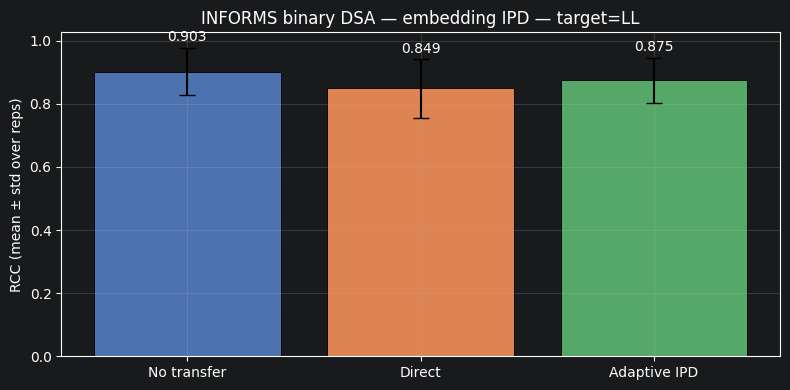

Summary (INFORMS binary): {'no_transfer': (np.float64(0.9025000000000001), np.float64(0.07530493565054906)), 'direct_transfer': (np.float64(0.8491666666666667), np.float64(0.09284844281587781)), 'adaptive_ipd': (np.float64(0.875), np.float64(0.07168604389202189))}


In [5]:
from pyhealth.datasets import create_sample_dataset
from typing import Optional

# --- INFORMS binary DSA + IPD-ranked transfer (paper task; uses global IPD_METRIC) ---
INFORMS_TRAIN_SUBJECTS = 6
BINARY_REPS = 5  # paper uses 15
EPOCHS_PRETRAIN_INFORMS = 2
EPOCHS_FINETUNE_INFORMS = 6
BINARY_BATCH = 16
MAX_IPD_TRAIN_SAMPLES = 350  # subsample training segments for DTW IPD speed
PROBE_EMBEDDING_EPOCHS = 1  # short target probe before embedding IPD


def informs_subject_split(
    all_subjects: Sequence[str],
    n_train: int,
    seed: int,
) -> Tuple[set, set]:
    rng = np.random.default_rng(seed)
    ids = list(all_subjects)
    rng.shuffle(ids)
    train_s = set(ids[:n_train])
    val_s = set(ids[n_train:])
    return train_s, val_s


def samples_for_subjects(
    sample_ds,
    subjects: set,
    positive_class: int,
) -> List[dict]:
    rows: List[dict] = []
    for i in range(len(sample_ds)):
        s = sample_ds[i]
        pid = s["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid not in subjects:
            continue
        sig = s["signal"]
        if hasattr(sig, "detach"):
            sig = sig.cpu().float().numpy()
        y = int(s["label"].item()) if hasattr(s["label"], "item") else int(s["label"])
        y_bin = 1 if y == positive_class else 0
        rows.append(
            {
                "patient_id": pid,
                "visit_id": str(s.get("sample_id", f"s{i}")),
                "signal": sig,
                "label": y_bin,
            }
        )
    return rows


def balance_train_bootstrap(
    samples: List[dict], rng: np.random.Generator
) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    if len(pos) < len(neg):
        idx = rng.integers(0, len(pos), size=len(neg))
        pos = [dict(pos[i]) for i in idx]
    elif len(neg) < len(pos):
        idx = rng.integers(0, len(neg), size=len(pos))
        neg = [dict(neg[i]) for i in idx]
    out = pos + neg
    rng.shuffle(out)
    return out


def balance_val_downsample_neg(
    samples: List[dict], rng: np.random.Generator
) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    n = min(len(pos), len(neg))
    rng.shuffle(pos)
    rng.shuffle(neg)
    out = pos[:n] + neg[:n]
    rng.shuffle(out)
    return out


def indices_on_patients(sample_ds, subjects: set) -> List[int]:
    idx: List[int] = []
    for i in range(len(sample_ds)):
        pid = sample_ds[i]["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid in subjects:
            idx.append(i)
    return idx


def mean_ipd_train_segments(
    ipd_model: Optional[AdaptiveTransferModel],
    ds_src,
    ds_tgt,
    train_indices: Sequence[int],
    batch_size: int = 48,
    *,
    rng: Optional[np.random.Generator] = None,
) -> float:
    vals: List[float] = []
    all_d: List[float] = []
    for i in range(0, len(train_indices), batch_size):
        chunk = list(train_indices[i : i + batch_size])
        rows_s = [ds_src[j] for j in chunk]
        rows_t = [ds_tgt[j] for j in chunk]
        ba = collate_fn_dict_with_padding(rows_s)
        bb = collate_fn_dict_with_padding(rows_t)
        if IPD_METRIC == "embedding":
            if ipd_model is None:
                raise ValueError("embedding IPD requires ipd_model.")
            vals.append(ipd_model.compute_ipd(ba, bb))
        else:
            all_d.extend(paired_multivariate_dtw_distances(ba, bb).tolist())
    if IPD_METRIC == "embedding":
        return float(np.mean(vals))
    return summarize_ipd_distances(
        np.array(all_d, dtype=np.float64),
        use_paper_kde=IPD_USE_PAPER_KDE,
        kde_bandwidth=IPD_KDE_BANDWIDTH,
        kde_n_draws=IPD_KDE_DRAWS,
        kde_random_state=IPD_KDE_RANDOM_STATE,
        use_gaussian_noise=(not IPD_USE_PAPER_KDE and IPD_USE_GAUSSIAN_NOISE),
        noise_std=IPD_KDE_NOISE_STD,
        rng=rng,
    )


def build_binary_sample_dataset(raw: List[dict], name: str):
    return create_sample_dataset(
        samples=raw,
        input_schema={"signal": "tensor"},
        output_schema={"label": "multiclass"},
        dataset_name=name,
        in_memory=True,
    )


base_informs = DSADataset(root=str(DSA_ROOT), num_workers=1)
ds_by_unit: Dict[str, object] = {}
for u in ALL_UNITS:
    ds_by_unit[u] = base_informs.set_task(
        DSAActivityClassification(
            dataset_root=str(DSA_ROOT),
            selected_units=(u,),
        ),
        num_workers=1,
    )
all_subjects = sorted(ds_by_unit[TARGET_UNIT].patient_to_index.keys())
assert len(all_subjects) == 8, f"Expected 8 DSA subjects, got {len(all_subjects)}"

informs_results: Dict[str, List[float]] = {
    "no_transfer": [],
    "direct_transfer": [],
    "adaptive_ipd": [],
}

for rep in range(BINARY_REPS):
    rng = np.random.default_rng(SEED + rep * 997)
    train_subj, val_subj = informs_subject_split(
        all_subjects, INFORMS_TRAIN_SUBJECTS, seed=SEED + rep * 13
    )
    pos_class = int(rng.integers(0, 19))

    train_ds_u: Dict[str, object] = {}
    val_ds_u: Dict[str, object] = {}
    for u in ALL_UNITS:
        raw_tr = samples_for_subjects(ds_by_unit[u], train_subj, pos_class)
        raw_va = samples_for_subjects(ds_by_unit[u], val_subj, pos_class)
        raw_tr = balance_train_bootstrap(raw_tr, rng)
        raw_va = balance_val_downsample_neg(raw_va, rng)
        if not raw_tr or not raw_va:
            train_ds_u[u] = None
            val_ds_u[u] = None
            continue
        train_ds_u[u] = build_binary_sample_dataset(
            raw_tr, f"informs_tr_{rep}_{u}"
        )
        val_ds_u[u] = build_binary_sample_dataset(
            raw_va, f"informs_va_{rep}_{u}"
        )

    if any(train_ds_u[u] is None for u in ALL_UNITS):
        print(f"rep {rep}: skip (empty domain); pos=A{pos_class + 1:02d}")
        continue

    idx_ipd = indices_on_patients(ds_by_unit[TARGET_UNIT], train_subj)
    rng.shuffle(idx_ipd)
    idx_ipd = idx_ipd[: min(len(idx_ipd), MAX_IPD_TRAIN_SAMPLES)]

    ipd_model: Optional[AdaptiveTransferModel] = None
    if IPD_METRIC == "embedding":
        ipd_model = AdaptiveTransferModel(
            dataset=train_ds_u[TARGET_UNIT],
            feature_key="signal",
            hidden_dim=64,
            num_layers=1,
            dropout=0.2,
            backbone="lstm",
            distance_fn="euclidean",
            use_similarity_weighting=True,
            use_kde_smoothing=True,
        ).to(DEVICE)
        if PROBE_EMBEDDING_EPOCHS > 0:
            train_with_trainer(
                ipd_model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                epochs=PROBE_EMBEDDING_EPOCHS,
                lr=1e-3,
                monitor="accuracy",
            )

    ipd_src_to_tgt: Dict[str, float] = {}
    for s in SOURCE_UNITS:
        ipd_src_to_tgt[s] = mean_ipd_train_segments(
            ipd_model,
            ds_by_unit[s],
            ds_by_unit[TARGET_UNIT],
            idx_ipd,
            rng=rng,
        )
    ranked_sources = sorted(SOURCE_UNITS, key=lambda u: ipd_src_to_tgt[u])
    canonical_sources = list(SOURCE_UNITS)

    total_target_epochs = EPOCHS_PRETRAIN_INFORMS + EPOCHS_FINETUNE_INFORMS
    base_lr = 5e-3

    for mode in ("no_transfer", "direct_transfer", "adaptive_ipd"):
        model = AdaptiveTransferModel(
            dataset=train_ds_u[TARGET_UNIT],
            feature_key="signal",
            hidden_dim=64,
            num_layers=1,
            dropout=0.2,
            backbone="lstm",
            use_similarity_weighting=(mode == "adaptive_ipd"),
            use_kde_smoothing=True,
        ).to(DEVICE)

        if mode == "no_transfer":
            train_with_trainer(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                epochs=total_target_epochs,
                lr=base_lr,
                monitor="accuracy",
            )
        elif mode == "direct_transfer":
            for s in canonical_sources:
                train_with_trainer(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    epochs=EPOCHS_PRETRAIN_INFORMS,
                    lr=base_lr,
                    monitor="accuracy",
                )
            train_with_trainer(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                epochs=EPOCHS_FINETUNE_INFORMS,
                lr=base_lr,
                monitor="accuracy",
            )
        else:
            for s in ranked_sources:
                sim = 1.0 / (ipd_src_to_tgt[s] + 1e-8)
                lr = model.get_adaptive_lr(base_lr, sim)
                train_with_trainer(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    epochs=EPOCHS_PRETRAIN_INFORMS,
                    lr=lr,
                    monitor="accuracy",
                )
            train_with_trainer(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                epochs=EPOCHS_FINETUNE_INFORMS,
                lr=base_lr,
                monitor="accuracy",
            )

        acc = evaluate_accuracy(
            model,
            get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
        )
        informs_results[mode].append(acc)
        print(
            f"rep {rep} {mode}: pos=A{pos_class + 1:02d} RCC={acc:.4f} | "
            f"IPD rank: {ranked_sources}"
        )

# --- Comparison chart ---
labels_short = ["No transfer", "Direct", "Adaptive IPD"]
keys = ["no_transfer", "direct_transfer", "adaptive_ipd"]
means = [float(np.mean(informs_results[k])) if informs_results[k] else 0.0 for k in keys]
stds = [float(np.std(informs_results[k])) if informs_results[k] else 0.0 for k in keys]
xpos = np.arange(len(keys))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    xpos,
    means,
    yerr=stds,
    capsize=6,
    color=["#4c72b0", "#dd8452", "#55a868"],
    edgecolor="black",
    linewidth=0.6,
)
ax.set_xticks(xpos)
ax.set_xticklabels(labels_short)
ax.set_ylabel("RCC (mean ± std over reps)")
ax.set_title(
    f"INFORMS binary DSA — embedding IPD — target={TARGET_UNIT}"
)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print("Summary (INFORMS binary):", {k: (np.mean(v), np.std(v)) for k, v in informs_results.items() if v})

del base_informs, ds_by_unit



In [6]:
# Load base DSA once; task-specific caches are separate per unit.
base_dsa = DSADataset(root=str(DSA_ROOT), num_workers=1)

template_task = DSAActivityClassification(
    dataset_root=str(DSA_ROOT),
    selected_units=(ALL_UNITS[0],),
)
template_full = base_dsa.set_task(template_task, num_workers=1)
split = patient_split_indices(template_full, seed=SEED)
bundles = build_domain_datasets(base_dsa, DSA_ROOT, ALL_UNITS, split, num_workers=1)

val_idx = split["val"]
tgt = bundles[TARGET_UNIT]

# sanity: aligned sample_id across units
for u in ALL_UNITS:
    for i in (0, 1000, 9000):
        assert bundles[u].full[i]["sample_id"] == bundles[ALL_UNITS[0]].full[i]["sample_id"]
print("Sample alignment OK across domains.")
print("Train/val/test sizes:", len(split["train"]), len(val_idx), len(split["test"]))


No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

IPD_METRIC=dtw: skipping probe training (DTW on raw segments).


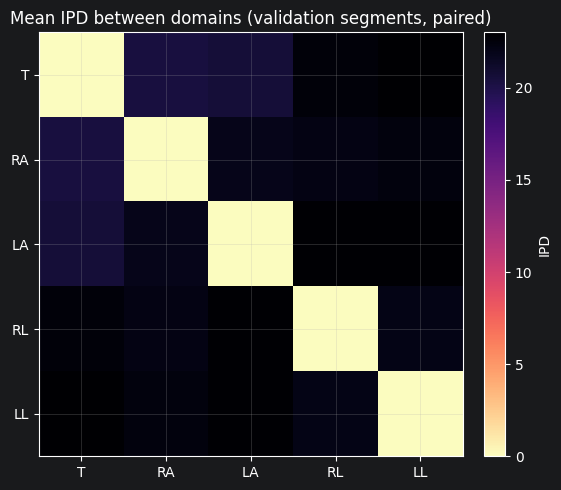

Sources ranked by similarity to target (low IPD first): ['RL', 'RA', 'LA', 'T']
IPD to target: {'T': 23.0136, 'RA': 22.4378, 'LA': 22.8829, 'RL': 22.0935}


In [7]:
# --- Probe model: only used when IPD_METRIC == "embedding" ---
probe: Optional[AdaptiveTransferModel] = None
if IPD_METRIC == "embedding":
    probe_ds = tgt.train
    probe_train_loader, probe_val_loader, _ = make_loaders(
        probe_ds, bundles[TARGET_UNIT].val, bundles[TARGET_UNIT].test
    )
    probe = AdaptiveTransferModel(
        dataset=probe_ds,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn="euclidean",
        use_similarity_weighting=True,
        use_kde_smoothing=True,
    ).to(DEVICE)
    train_with_trainer(
        probe,
        probe_train_loader,
        probe_val_loader,
        epochs=EPOCHS_PROBE,
        lr=1e-3,
    )
else:
    print("IPD_METRIC=dtw: skipping probe training (DTW on raw segments).")

ipd_mat = ipd_similarity_matrix(probe, bundles, ALL_UNITS, val_idx)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ipd_mat, cmap="magma_r")
ax.set_xticks(range(len(ALL_UNITS)))
ax.set_yticks(range(len(ALL_UNITS)))
ax.set_xticklabels(ALL_UNITS)
ax.set_yticklabels(ALL_UNITS)
ax.set_title("Mean IPD between domains (validation segments, paired)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="IPD")
plt.tight_layout()
plt.show()

# Similarities from each source to target (lower IPD => more similar)
src_to_tgt = {
    s: mean_ipd_between(probe, bundles[s].full, bundles[TARGET_UNIT].full, val_idx)
    for s in SOURCE_UNITS
}
ranked_sources = sorted(SOURCE_UNITS, key=lambda u: src_to_tgt[u])
print("Sources ranked by similarity to target (low IPD first):", ranked_sources)
print("IPD to target:", {k: round(v, 4) for k, v in src_to_tgt.items()})


=== no_transfer ===
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14e6bab50>
Monitor: accuracy
Monitor criterion: max
Epochs: 13
Patience: None



Epoch 0 / 13: 100%|██████████| 72/72 [00:01<00:00, 51.96it/s]

--- Train epoch-0, step-72 ---
loss: 2.9026



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 159.53it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.0667
loss: 2.9528
New best accuracy score (0.0667) at epoch-0, step-72



...

--- Train epoch-4, step-360 ---
loss: 2.5286



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 158.25it/s]

--- Eval epoch-4, step-360 ---
accuracy: 0.1838
loss: 2.7120
New best accuracy score (0.1838) at epoch-4, step-360
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 210.44it/s]


test accuracy: 0.1864


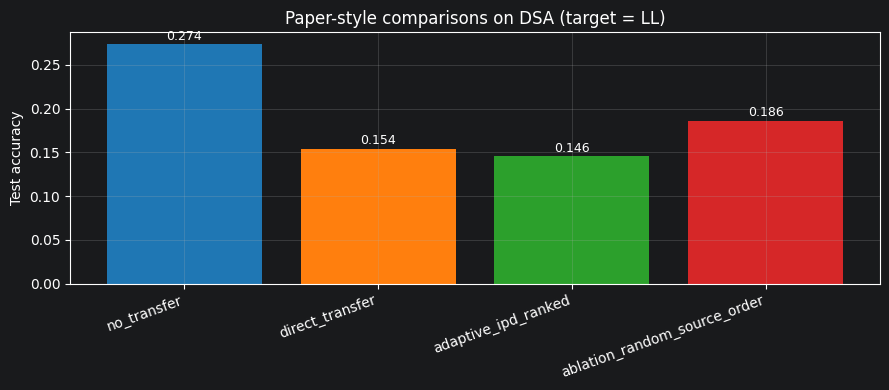

In [8]:
@dataclass
class TrainConfig:
    name: str
    pretrain_order: List[str]
    use_adaptive_lr: bool
    base_lr: float = 1e-3
    model_distance: str = "euclidean"
    use_kde_smoothing: bool = True
    use_similarity_weighting: bool = True


def run_experiment(cfg: TrainConfig) -> float:
    target_train = bundles[TARGET_UNIT].train
    target_val = bundles[TARGET_UNIT].val
    target_test = bundles[TARGET_UNIT].test
    tr_l, va_l, te_l = make_loaders(target_train, target_val, target_test)

    model = AdaptiveTransferModel(
        dataset=target_train,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn=cfg.model_distance,
        use_similarity_weighting=cfg.use_similarity_weighting,
        use_kde_smoothing=cfg.use_kde_smoothing,
    ).to(DEVICE)

    if cfg.name == "no_transfer":
        total_epochs = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
        train_with_trainer(model, tr_l, va_l, epochs=total_epochs, lr=cfg.base_lr)
        return evaluate_accuracy(model, te_l)

    for src in cfg.pretrain_order:
        src_train = bundles[src].train
        s_tr, s_va, _ = make_loaders(src_train, bundles[src].val, bundles[src].test)
        sim = 1.0 / (mean_ipd_between(probe, bundles[src].full, bundles[TARGET_UNIT].full, val_idx) + 1e-8)
        lr = (
            model.get_adaptive_lr(cfg.base_lr, sim)
            if cfg.use_adaptive_lr
            else cfg.base_lr
        )
        train_with_trainer(
            model,
            s_tr,
            s_va,
            epochs=EPOCHS_PRETRAIN_PER_SOURCE,
            lr=lr,
        )

    train_with_trainer(model, tr_l, va_l, epochs=EPOCHS_FINETUNE, lr=cfg.base_lr)
    return evaluate_accuracy(model, te_l)


canonical_source_order = list(SOURCE_UNITS)
random_order = canonical_source_order.copy()
random.Random(SEED).shuffle(random_order)

main_experiments = [
    TrainConfig("no_transfer", [], False),
    TrainConfig(
        "direct_transfer",
        canonical_source_order,
        use_adaptive_lr=False,
    ),
    TrainConfig(
        "adaptive_ipd_ranked",
        ranked_sources,
        use_adaptive_lr=True,
    ),
    TrainConfig(
        "ablation_random_source_order",
        random_order,
        use_adaptive_lr=True,
    ),
]

results_main = {}
for cfg in main_experiments:
    print("===", cfg.name, "===")
    acc = run_experiment(cfg)
    results_main[cfg.name] = acc
    print(f"test accuracy: {acc:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
names = list(results_main.keys())
accs = [results_main[k] for k in names]
xpos = np.arange(len(names))
_cmap = plt.get_cmap("tab10")
ax.bar(xpos, accs, color=[_cmap(i % 10) for i in range(len(names))])
ax.set_xticks(xpos)
ax.set_ylabel("Test accuracy")
ax.set_title("Paper-style comparisons on DSA (target = " + TARGET_UNIT + ")")
ax.set_xticklabels(names, rotation=20, ha="right")
for i, v in enumerate(accs):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


=== ablation: adaptive_default ===
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 4.526226395053778e-05}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14a830150>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 65.93it/s] 

--- Train epoch-0, step-72 ---
loss: 2.9459



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 154.76it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.0491
loss: 2.9447
New best accuracy score (0.0491) at epoch-0, step-72



...

--- Train epoch-4, step-360 ---
loss: 2.8968



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 165.96it/s]

--- Eval epoch-4, step-360 ---
accuracy: 0.0596
loss: 2.9122
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 212.49it/s]


accuracy: 0.12017543859649123


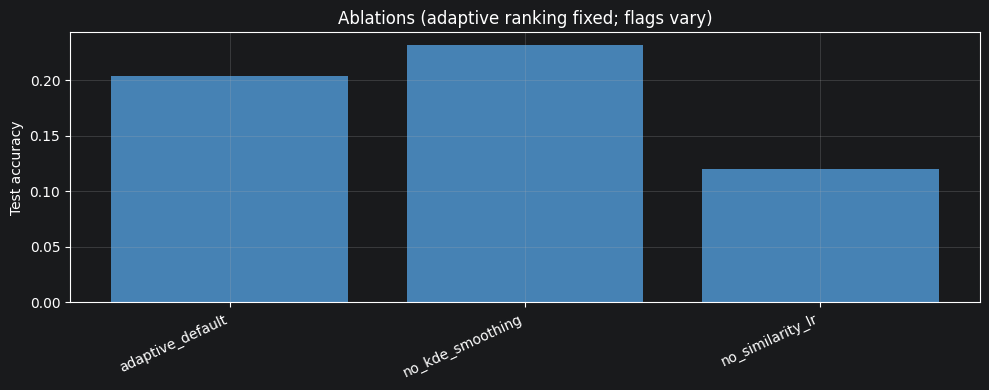

In [9]:
# --- Ablations on AdaptiveTransferModel flags (IPD-ranked pipeline) ---
ablation_configs = [
    ("adaptive_default", "euclidean", True, True),
    ("no_kde_smoothing", "euclidean", True, False),
    ("no_similarity_lr", "euclidean", False, True),
    ("distance_cosine", "cosine", True, True),
    ("distance_manhattan", "manhattan", True, True),
]

if not RUN_FULL_ABLATIONS:
    ablation_configs = ablation_configs[:3]

results_ab = {}
for name, dist, sim_w, kde in ablation_configs:
    cfg = TrainConfig(
        name=name,
        pretrain_order=ranked_sources,
        use_adaptive_lr=sim_w,
        model_distance=dist,
        use_kde_smoothing=kde,
        use_similarity_weighting=sim_w,
    )
    print("=== ablation:", name, "===")
    results_ab[name] = run_experiment(cfg)
    print("accuracy:", results_ab[name])

fig, ax = plt.subplots(figsize=(10, 4))
keys = list(results_ab.keys())
vals = [results_ab[k] for k in keys]
xpos = np.arange(len(keys))
ax.bar(xpos, vals, color="steelblue")
ax.set_xticks(xpos)
ax.set_ylabel("Test accuracy")
ax.set_title("Ablations (adaptive ranking fixed; flags vary)")
ax.set_xticklabels(keys, rotation=25, ha="right")
plt.tight_layout()
plt.show()


Training model for noise curve: no_transfer …
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x13d7c8d50>
Monitor: accuracy
Monitor criterion: max
Epochs: 13
Patience: None



Epoch 0 / 13: 100%|██████████| 72/72 [00:01<00:00, 45.35it/s]

--- Train epoch-0, step-72 ---
loss: 2.9044



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 162.95it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1566
loss: 2.7595
New best accuracy score (0.1566) at epoch-0, step-72



...

--- Eval epoch-3, step-288 ---
accuracy: 0.0548
loss: 3.0686




Epoch 4 / 5: 100%|██████████| 72/72 [00:01<00:00, 67.39it/s] 

--- Train epoch-4, step-360 ---
loss: 2.8006



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 162.52it/s]

--- Eval epoch-4, step-360 ---
accuracy: 0.0982
loss: 2.8181


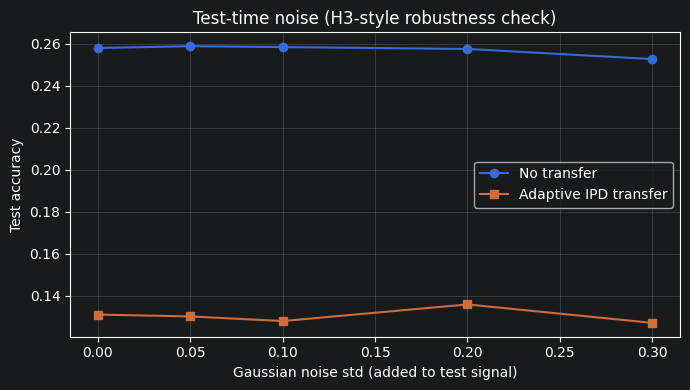

In [10]:
# --- Noise robustness (best main config vs no transfer) ---
# Re-train two fresh models and sweep test-time noise

def train_model_for_noise(mode: str) -> AdaptiveTransferModel:
    target_train = bundles[TARGET_UNIT].train
    target_val = bundles[TARGET_UNIT].val
    tr_l, va_l, _ = make_loaders(target_train, target_val, target_test)
    model = AdaptiveTransferModel(
        dataset=target_train,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
    ).to(DEVICE)
    if mode == "no_transfer":
        total_epochs = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
        train_with_trainer(model, tr_l, va_l, epochs=total_epochs, lr=1e-3)
        return model
    for src in ranked_sources:
        src_train = bundles[src].train
        s_tr, s_va, _ = make_loaders(src_train, bundles[src].val, bundles[src].test)
        sim = 1.0 / (mean_ipd_between(probe, bundles[src].full, bundles[TARGET_UNIT].full, val_idx) + 1e-8)
        lr = model.get_adaptive_lr(1e-3, sim)
        train_with_trainer(model, s_tr, s_va, epochs=EPOCHS_PRETRAIN_PER_SOURCE, lr=lr)
    train_with_trainer(model, tr_l, va_l, epochs=EPOCHS_FINETUNE, lr=1e-3)
    return model


target_test = bundles[TARGET_UNIT].test
_, _, test_loader_noise = make_loaders(
    bundles[TARGET_UNIT].train,
    bundles[TARGET_UNIT].val,
    target_test,
)

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3]
print("Training model for noise curve: no_transfer …")
m0 = train_model_for_noise("no_transfer")
acc0 = accuracy_under_noise(m0, test_loader_noise, noise_levels)

print("Training model for noise curve: adaptive_ipd …")
m1 = train_model_for_noise("adaptive_ipd")
acc1 = accuracy_under_noise(m1, test_loader_noise, noise_levels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(noise_levels, acc0, marker="o", label="No transfer")
ax.plot(noise_levels, acc1, marker="s", label="Adaptive IPD transfer")
ax.set_xlabel("Gaussian noise std (added to test signal)")
ax.set_ylabel("Test accuracy")
ax.set_title("Test-time noise (H3-style robustness check)")
ax.legend()
plt.tight_layout()
plt.show()


## References

- Barshan & Altun (2010). Daily and Sports Activities. UCI ML Repository.
- Zhang et al., *Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data* (paper under reproduction in DL4H / PyHealth).
- PyHealth: https://pyhealth.readthedocs.io/
